# Notebook 03: Baseline RAG - Retrieval Strategies & Complete Pipeline

## Overview

In this notebook, we will:
1. Implement multiple retrieval strategies (Vector, BM25, Hybrid)
2. Compare retrieval quality across approaches
3. Build a complete RAG pipeline with LLM generation
4. Add conversation memory
5. Implement source attribution
6. Evaluate RAG performance

**Learning Objectives:**
- Understand different retrieval approaches and tradeoffs
- See how vector search compares to keyword search (BM25)
- Learn why hybrid search often works best
- Build production-ready RAG with memory and citations
- Evaluate answer quality and relevance

---

## 1. Setup and Configuration

In [1]:
import os
import json
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
from dotenv import load_dotenv
from openai import OpenAI
from datetime import datetime

# Load environment variables
load_dotenv()

# Configuration
KNOWLEDGE_BASE_ID = os.getenv('KNOWLEDGE_BASE_ID')
AWS_REGION = os.getenv('AWS_DEFAULT_REGION', 'us-east-1')
LLM_BASE_URL = os.getenv('LLM_BASE_URL')
LLM_API_KEY = os.getenv('LLM_API_KEY')
LLM_MODEL = os.getenv('LLM_MODEL', 'gpt-4o')

# Initialize clients
bedrock_agent_runtime = boto3.client('bedrock-agent-runtime', region_name=AWS_REGION)
llm_client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("[OK] Configuration loaded")
print(f"  Knowledge Base ID: {KNOWLEDGE_BASE_ID}")
print(f"  LLM Model: {LLM_MODEL}")
print(f"  Region: {AWS_REGION}")

[OK] Configuration loaded
  Knowledge Base ID: HAMKFMPMEM
  LLM Model: gpt-4o
  Region: us-east-1


/Users/apalakkode/Library/CloudStorage/OneDrive-PayPal/Agentic RAG/ecommerce-chatbot/venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


---

## 2. Load and Prepare Local Knowledge Base

For BM25 and hybrid search, we need the raw chunks locally.

In [2]:
# Load chunks from local file
with open('../data/knowledge_base_chunks.json', 'r') as f:
    chunks = json.load(f)

print(f"[OK] Loaded {len(chunks)} chunks")
print(f"  Policy chunks: {sum(1 for c in chunks if c['source'] != 'faq')}")
print(f"  FAQ chunks: {sum(1 for c in chunks if c['source'] == 'faq')}")

# Display sample chunk
print("\nSample chunk structure:")
print("-"*80)
print(json.dumps(chunks[0], indent=2))

[OK] Loaded 93 chunks
  Policy chunks: 14
  FAQ chunks: 79

Sample chunk structure:
--------------------------------------------------------------------------------
{
  "chunk_id": "return_policy_0",
  "source": "return_policy",
  "text": "Return Policy\n\nEligibility for Returns\nItems can be returned within 30 days of delivery. To be eligible for a return, items must be in their original condition with all tags attached. Damaged or defective items qualify for a full refund with no restocking fee. For returns due to change of mind, a 15% restocking fee will be applied to the refund amount.",
  "chunk_index": 0,
  "total_chunks": 5
}


---

## 3. Retrieval Strategy 1: Vector Search (Semantic)

Uses embeddings to find semantically similar content.

In [3]:
def vector_search(query: str, num_results: int = 5) -> List[Dict]:
    """
    Retrieve documents using vector similarity search via Bedrock Knowledge Base.
    
    How it works:
    1. Query is converted to embedding vector
    2. Cosine similarity computed against all document vectors
    3. Top K most similar documents returned
    """
    response = bedrock_agent_runtime.retrieve(
        knowledgeBaseId=KNOWLEDGE_BASE_ID,
        retrievalQuery={'text': query},
        retrievalConfiguration={
            'vectorSearchConfiguration': {
                'numberOfResults': num_results
            }
        }
    )
    
    results = []
    for result in response.get('retrievalResults', []):
        results.append({
            'text': result['content']['text'],
            'score': result['score'],
            'source': result['location']['s3Location']['uri'],
            'method': 'vector'
        })
    
    return results

# Test vector search
test_query = "What is your return policy?"

print(f"Query: '{test_query}'")
print("="*80)

vector_results = vector_search(test_query, num_results=3)

print(f"\nVector Search Results: {len(vector_results)} documents\n")
for idx, result in enumerate(vector_results, 1):
    print(f"Result {idx} (Score: {result['score']:.4f})")
    print(f"  Source: {result['source'].split('/')[-1]}")
    print(f"  Content: {result['text'][:150]}...")
    print()

Query: 'What is your return policy?'

Vector Search Results: 3 documents

Result 1 (Score: 0.5944)
  Source: faq_3.txt
  Content: Q: What is your return policy?
A: Our return policy allows you to return products within 30 days of purchase for a full refund, provided they are in t...

Result 2 (Score: 0.4681)
  Source: return_policy_0.txt
  Content: Return Policy

Eligibility for Returns
Items can be returned within 30 days of delivery. To be eligible for a return, items must be in their original ...

Result 3 (Score: 0.4512)
  Source: return_policy_1.txt
  Content: Return Process
To initiate a return, submit a return request through your account dashboard with your order number. Once approved, you will receive a ...



---

## 4. Retrieval Strategy 2: BM25 (Keyword Search)

Classic keyword-based retrieval using term frequency.

In [4]:
# Install rank_bm25
!pip install -q rank_bm25

In [5]:
from rank_bm25 import BM25Okapi
import re

def tokenize(text: str) -> List[str]:
    """Simple tokenization: lowercase and split on non-alphanumeric."""
    return re.findall(r'\w+', text.lower())

# Prepare BM25 index
print("Building BM25 index...")
corpus = [chunk['text'] for chunk in chunks]
tokenized_corpus = [tokenize(doc) for doc in corpus]
bm25 = BM25Okapi(tokenized_corpus)
print(f"[OK] BM25 index built with {len(corpus)} documents")

def bm25_search(query: str, num_results: int = 5) -> List[Dict]:
    """
    Retrieve documents using BM25 keyword search.
    
    How it works:
    1. Query tokenized into keywords
    2. TF-IDF style scoring: rewards term frequency, penalizes common terms
    3. Top K documents by BM25 score returned
    """
    tokenized_query = tokenize(query)
    scores = bm25.get_scores(tokenized_query)
    
    # Get top K indices
    top_indices = np.argsort(scores)[::-1][:num_results]
    
    results = []
    for idx in top_indices:
        if scores[idx] > 0:  # Only return if score > 0
            results.append({
                'text': chunks[idx]['text'],
                'score': float(scores[idx]),
                'source': chunks[idx]['chunk_id'],
                'method': 'bm25'
            })
    
    return results

# Test BM25 search
print(f"\nQuery: '{test_query}'")
print("="*80)

bm25_results = bm25_search(test_query, num_results=3)

print(f"\nBM25 Search Results: {len(bm25_results)} documents\n")
for idx, result in enumerate(bm25_results, 1):
    print(f"Result {idx} (Score: {result['score']:.4f})")
    print(f"  Source: {result['source']}")
    print(f"  Content: {result['text'][:150]}...")
    print()

Building BM25 index...
[OK] BM25 index built with 93 documents

Query: 'What is your return policy?'

BM25 Search Results: 3 documents

Result 1 (Score: 8.1837)
  Source: faq_3
  Content: Q: What is your return policy?
A: Our return policy allows you to return products within 30 days of purchase for a full refund, provided they are in t...

Result 2 (Score: 5.8866)
  Source: faq_11
  Content: Q: What is your price matching policy?
A: We have a price matching policy where we will match the price of an identical product found on a competitor'...

Result 3 (Score: 5.3998)
  Source: faq_14
  Content: Q: What is your price adjustment policy?
A: If a product you purchased goes on sale within 7 days of your purchase, we offer a one-time price adjustme...



---

## 5. Retrieval Strategy 3: Hybrid Search

Combines vector and BM25 for best of both worlds.

hybrid_score = α × vector_score + (1-α) × bm25_score

In [6]:
def normalize_scores(results: List[Dict]) -> List[Dict]:
    """Normalize scores to 0-1 range."""
    if not results:
        return results
    
    scores = [r['score'] for r in results]
    min_score = min(scores)
    max_score = max(scores)
    
    if max_score == min_score:
        for r in results:
            r['normalized_score'] = 1.0
    else:
        for r in results:
            r['normalized_score'] = (r['score'] - min_score) / (max_score - min_score)
    
    return results

def hybrid_search(query: str, num_results: int = 5, alpha: float = 0.5) -> List[Dict]:
    """
    Retrieve documents using hybrid search (vector + BM25).
    
    Args:
        query: Search query
        num_results: Number of results to return
        alpha: Weight for vector search (0-1). 
               alpha=1.0: pure vector, alpha=0.0: pure BM25, alpha=0.5: balanced
    
    How it works:
    1. Get results from both vector and BM25
    2. Normalize scores to 0-1 range
    3. Combine: hybrid_score = alpha * vector_score + (1-alpha) * bm25_score
    4. Re-rank and return top K
    """
    # Get results from both methods
    vector_results = vector_search(query, num_results=num_results * 2)
    bm25_results = bm25_search(query, num_results=num_results * 2)
    
    # Normalize scores
    vector_results = normalize_scores(vector_results)
    bm25_results = normalize_scores(bm25_results)
    
    # Combine results using a dict keyed by content
    combined = {}
    
    for result in vector_results:
        text = result['text']
        combined[text] = {
            'text': text,
            'source': result['source'],
            'vector_score': result['normalized_score'],
            'bm25_score': 0.0,
            'method': 'hybrid'
        }
    
    for result in bm25_results:
        text = result['text']
        if text in combined:
            combined[text]['bm25_score'] = result['normalized_score']
        else:
            combined[text] = {
                'text': text,
                'source': result['source'],
                'vector_score': 0.0,
                'bm25_score': result['normalized_score'],
                'method': 'hybrid'
            }
    
    # Calculate hybrid scores
    for text in combined:
        combined[text]['score'] = (
            alpha * combined[text]['vector_score'] + 
            (1 - alpha) * combined[text]['bm25_score']
        )
    
    # Sort by hybrid score and return top K
    sorted_results = sorted(combined.values(), key=lambda x: x['score'], reverse=True)
    return sorted_results[:num_results]

# Test hybrid search
print(f"Query: '{test_query}'")
print("="*80)

hybrid_results = hybrid_search(test_query, num_results=3, alpha=0.5)

print(f"\nHybrid Search Results (alpha=0.5): {len(hybrid_results)} documents\n")
for idx, result in enumerate(hybrid_results, 1):
    print(f"Result {idx} (Hybrid Score: {result['score']:.4f})")
    print(f"  Vector: {result['vector_score']:.4f}, BM25: {result['bm25_score']:.4f}")
    print(f"  Source: {result['source'].split('/')[-1] if '/' in result['source'] else result['source']}")
    print(f"  Content: {result['text'][:150]}...")
    print()

Query: 'What is your return policy?'

Hybrid Search Results (alpha=0.5): 3 documents

Result 1 (Hybrid Score: 1.0000)
  Vector: 1.0000, BM25: 1.0000
  Source: faq_3.txt
  Content: Q: What is your return policy?
A: Our return policy allows you to return products within 30 days of purchase for a full refund, provided they are in t...

Result 2 (Hybrid Score: 0.2318)
  Vector: 0.0000, BM25: 0.4635
  Source: faq_11
  Content: Q: What is your price matching policy?
A: We have a price matching policy where we will match the price of an identical product found on a competitor'...

Result 3 (Hybrid Score: 0.1749)
  Vector: 0.0000, BM25: 0.3498
  Source: faq_14
  Content: Q: What is your price adjustment policy?
A: If a product you purchased goes on sale within 7 days of your purchase, we offer a one-time price adjustme...



---

## 6. Compare Retrieval Strategies

Test all three approaches on various queries.

In [7]:
# Test queries covering different scenarios
test_queries = [
    "What is your return policy?",
    "How long does shipping take?",
    "free shipping",
    "Can I return items after 30 days?",
    "warranty coverage",
    "track my order"
]

comparison_results = []

for query in test_queries:
    vector_res = vector_search(query, num_results=1)
    bm25_res = bm25_search(query, num_results=1)
    hybrid_res = hybrid_search(query, num_results=1, alpha=0.5)
    
    comparison_results.append({
        'Query': query[:40],
        'Vector Score': f"{vector_res[0]['score']:.3f}" if vector_res else '0.000',
        'BM25 Score': f"{bm25_res[0]['score']:.3f}" if bm25_res else '0.000',
        'Hybrid Score': f"{hybrid_res[0]['score']:.3f}" if hybrid_res else '0.000',
        'Vector Source': vector_res[0]['source'].split('/')[-1][:20] if vector_res else 'N/A',
        'BM25 Source': bm25_res[0]['source'].split('/')[-1][:20] if bm25_res else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_results)
print("\nRetrieval Strategy Comparison:")
print("="*120)
print(comparison_df.to_string(index=False))

print("\n" + "="*120)
print("\nKey Observations:")
print("-"*120)
print("- Vector Search: Better for semantic queries (longer, natural language)")
print("- BM25 Search: Better for exact keyword matches (short, specific terms)")
print("- Hybrid Search: Balanced approach, handles both semantic and keyword queries")


Retrieval Strategy Comparison:
                            Query Vector Score BM25 Score Hybrid Score        Vector Source       BM25 Source
      What is your return policy?        0.594      8.184        1.000            faq_3.txt             faq_3
     How long does shipping take?        0.524     19.601        1.000            faq_5.txt             faq_5
                    free shipping        0.450      6.668        1.000 shipping_policy_1.tx shipping_policy_1
Can I return items after 30 days?        0.491     10.705        1.000  return_policy_0.txt   return_policy_0
                warranty coverage        0.471      9.542        0.500 warranty_policy_1.tx warranty_policy_0
                   track my order        0.754      8.247        1.000            faq_2.txt             faq_2


Key Observations:
------------------------------------------------------------------------------------------------------------------------
- Vector Search: Better for semantic queries (longer, nat

---

## 7. Visualize Retrieval Performance

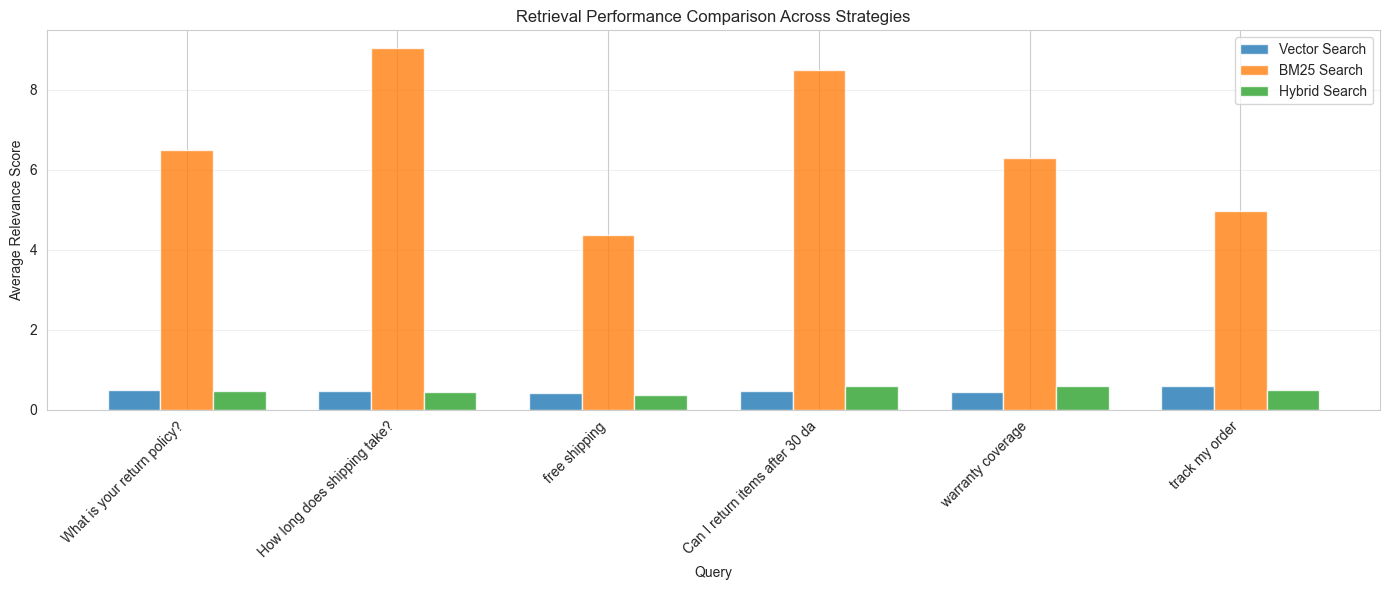


Average Scores Across All Queries:
------------------------------------------------------------
Vector Search:  0.4863
BM25 Search:    6.6081
Hybrid Search:  0.4946


In [8]:
# Collect detailed scores for visualization
detailed_comparison = []

for query in test_queries:
    vector_res = vector_search(query, num_results=3)
    bm25_res = bm25_search(query, num_results=3)
    hybrid_res = hybrid_search(query, num_results=3, alpha=0.5)
    
    avg_vector = np.mean([r['score'] for r in vector_res]) if vector_res else 0
    avg_bm25 = np.mean([r['score'] for r in bm25_res]) if bm25_res else 0
    avg_hybrid = np.mean([r['score'] for r in hybrid_res]) if hybrid_res else 0
    
    detailed_comparison.append({
        'Query': query[:30],
        'Vector': avg_vector,
        'BM25': avg_bm25,
        'Hybrid': avg_hybrid
    })

# Create visualization
df_viz = pd.DataFrame(detailed_comparison)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_viz))
width = 0.25

ax.bar(x - width, df_viz['Vector'], width, label='Vector Search', alpha=0.8)
ax.bar(x, df_viz['BM25'], width, label='BM25 Search', alpha=0.8)
ax.bar(x + width, df_viz['Hybrid'], width, label='Hybrid Search', alpha=0.8)

ax.set_xlabel('Query')
ax.set_ylabel('Average Relevance Score')
ax.set_title('Retrieval Performance Comparison Across Strategies')
ax.set_xticks(x)
ax.set_xticklabels(df_viz['Query'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nAverage Scores Across All Queries:")
print("-"*60)
print(f"Vector Search:  {df_viz['Vector'].mean():.4f}")
print(f"BM25 Search:    {df_viz['BM25'].mean():.4f}")
print(f"Hybrid Search:  {df_viz['Hybrid'].mean():.4f}")

---

## 8. Build Complete RAG Pipeline with LLM Generation

Now let's use retrieval + LLM to generate answers.

In [9]:
def generate_answer(query: str, retrieved_docs: List[Dict], include_sources: bool = True) -> Dict:
    """
    Generate answer using LLM with retrieved context.
    
    Args:
        query: User question
        retrieved_docs: List of retrieved documents from search
        include_sources: Whether to include source citations
    
    Returns:
        Dict with answer, sources, and metadata
    """
    # Build context from retrieved documents
    context_parts = []
    sources = []
    
    for idx, doc in enumerate(retrieved_docs, 1):
        context_parts.append(f"[Document {idx}]\n{doc['text']}")
        sources.append({
            'index': idx,
            'source': doc['source'],
            'score': doc['score']
        })
    
    context = "\n\n".join(context_parts)
    
    # Create prompt
    system_prompt = """You are a helpful customer service assistant for an e-commerce platform. 
Answer questions based on the provided context. Be concise, accurate, and friendly.

Guidelines:
- Only use information from the provided context
- If the context doesn't contain the answer, say so
- Cite document numbers when referencing specific information
- Keep answers clear and actionable"""
    
    user_prompt = f"""Context:
{context}

Question: {query}

Answer:"""
    
    # Generate response
    response = llm_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.1,
        max_tokens=500
    )
    
    answer = response.choices[0].message.content
    
    return {
        'query': query,
        'answer': answer,
        'sources': sources if include_sources else [],
        'num_sources': len(sources),
        'model': LLM_MODEL,
        'timestamp': datetime.now().isoformat()
    }

# Test RAG pipeline
test_question = "What is your return policy and how long does it take to get a refund?"

print(f"Question: {test_question}")
print("="*80)

# Retrieve context using hybrid search
retrieved = hybrid_search(test_question, num_results=3, alpha=0.5)

print(f"\nRetrieved {len(retrieved)} relevant documents")
print("-"*80)

# Generate answer
result = generate_answer(test_question, retrieved)

print("\nAnswer:")
print("-"*80)
print(result['answer'])
print()

print("\nSources:")
print("-"*80)
for source in result['sources']:
    source_name = source['source'].split('/')[-1] if '/' in source['source'] else source['source']
    print(f"  [{source['index']}] {source_name} (Score: {source['score']:.4f})")

Question: What is your return policy and how long does it take to get a refund?

Retrieved 3 relevant documents
--------------------------------------------------------------------------------

Answer:
--------------------------------------------------------------------------------
Our return policy allows you to return products within 30 days of purchase for a full refund, provided they are in their original condition and packaging (Document 1). Refunds are processed within 7-10 business days after we receive and inspect the returned item, and it may take an additional 3-5 business days for the refund to appear in your account, depending on your bank or card issuer (Document 3).


Sources:
--------------------------------------------------------------------------------
  [1] faq_3.txt (Score: 0.7678)
  [2] faq_5 (Score: 0.5000)
  [3] return_policy_2.txt (Score: 0.3738)


---

## 9. Add Conversation Memory

Implement memory to handle follow-up questions.

In [ ]:
class ConversationalRAG:
    """
    RAG system with conversation memory.
    Maintains chat history for context-aware responses.
    """
    
    def __init__(self, retrieval_method='hybrid', num_results=3, alpha=0.5):
        self.conversation_history = []
        self.retrieval_method = retrieval_method
        self.num_results = num_results
        self.alpha = alpha
        
    def retrieve(self, query: str) -> List[Dict]:
        """Retrieve documents using configured method."""
        if self.retrieval_method == 'vector':
            return vector_search(query, self.num_results)
        elif self.retrieval_method == 'bm25':
            return bm25_search(query, self.num_results)
        else:  # hybrid
            return hybrid_search(query, self.num_results, self.alpha)
    
    def chat(self, user_message: str) -> Dict:
        """Process user message with conversation context."""
        # Retrieve relevant documents
        retrieved_docs = self.retrieve(user_message)
        
        # Build context from retrieved docs
        context_parts = []
        for idx, doc in enumerate(retrieved_docs, 1):
            context_parts.append(f"[Document {idx}]\n{doc['text']}")
        context = "\n\n".join(context_parts)
        
        # Build messages with conversation history
        messages = [
            {
                "role": "system",
                "content": """You are a helpful customer service assistant for an e-commerce platform.
Answer questions based on the provided context and conversation history.
Be concise, accurate, and friendly. Maintain context from previous messages."""
            }
        ]
        
        # Add conversation history
        for msg in self.conversation_history[-4:]:  # Keep last 4 exchanges
            messages.append({"role": "user", "content": msg['user']})
            messages.append({"role": "assistant", "content": msg['assistant']})
        
        # Add current message with context
        messages.append({
            "role": "user",
            "content": f"""Context:
{context}

Question: {user_message}

Answer:"""
        })
        
        # Generate response
        response = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=messages,
            temperature=0.1,
            max_tokens=500
        )
        
        answer = response.choices[0].message.content
        
        # Update conversation history
        self.conversation_history.append({
            'user': user_message,
            'assistant': answer,
            'sources': [{'source': doc['source'], 'score': doc['score']} for doc in retrieved_docs],
            'timestamp': datetime.now().isoformat()
        })
        
        return {
            'answer': answer,
            'sources': retrieved_docs,
            'conversation_length': len(self.conversation_history)
        }
    
    def get_history(self) -> List[Dict]:
        """Get conversation history."""
        return self.conversation_history
    
    def clear_history(self):
        """Clear conversation history."""
        self.conversation_history = []

# Test conversational RAG
print("Testing Conversational RAG with Memory")
print("="*80)

chatbot = ConversationalRAG(retrieval_method='hybrid', num_results=3, alpha=0.5)

# Conversation flow
conversation = [
    "What is your return policy?",
    "How long does it take?",  # Follow-up referring to "it" from context
    "What items can't be returned?"
]

for idx, message in enumerate(conversation, 1):
    print(f"\n[Turn {idx}]")
    print(f"User: {message}")
    print("-"*80)
    
    result = chatbot.chat(message)
    
    print(f"Assistant: {result['answer']}")
    print()

Testing Conversational RAG with Memory

[Turn 1]
User: What is your return policy?
--------------------------------------------------------------------------------
Assistant: Our return policy allows you to return products within 30 days of purchase for a full refund, provided they are in their original condition and packaging. Please refer to our Returns page for detailed instructions.


[Turn 2]
User: How long does it take?
--------------------------------------------------------------------------------
Assistant: Shipping times vary depending on the destination and the shipping method chosen. Standard shipping usually takes 3-5 business days, while express shipping can take 1-2 business days.


[Turn 3]
User: What items can't be returned?
--------------------------------------------------------------------------------
Assistant: Certain items cannot be returned for hygiene and safety reasons. These include perishable goods such as food items and flowers, personal care items includin

---

## 10. Enhanced RAG with Source Attribution

Add structured citations to answers.

In [10]:
def rag_with_citations(query: str, retrieval_method='hybrid') -> str:
    """
    Generate answer with inline citations.
    """
    # Retrieve documents
    if retrieval_method == 'vector':
        docs = vector_search(query, num_results=3)
    elif retrieval_method == 'bm25':
        docs = bm25_search(query, num_results=3)
    else:
        docs = hybrid_search(query, num_results=3, alpha=0.5)
    
    # Build context with numbered sources
    context_parts = []
    for idx, doc in enumerate(docs, 1):
        context_parts.append(f"[Source {idx}]\n{doc['text']}")
    context = "\n\n".join(context_parts)
    
    # Prompt with citation instructions
    system_prompt = """You are a helpful customer service assistant.
Answer questions based on the provided sources.

IMPORTANT: Include inline citations using [Source X] format when referencing information.
Example: "Returns are accepted within 30 days [Source 1]."

At the end of your answer, list all sources you cited."""
    
    user_prompt = f"""Sources:
{context}

Question: {query}

Provide an answer with inline citations:"""
    
    response = llm_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.1,
        max_tokens=500
    )
    
    answer = response.choices[0].message.content
    
    # Append source details
    answer += "\n\n" + "="*80 + "\n"
    answer += "Source Details:\n"
    answer += "-"*80 + "\n"
    for idx, doc in enumerate(docs, 1):
        source_name = doc['source'].split('/')[-1] if '/' in doc['source'] else doc['source']
        answer += f"[Source {idx}] {source_name} (Relevance: {doc['score']:.4f})\n"
    
    return answer

# Test RAG with citations
test_query = "What is your shipping policy for international orders?"

print(f"Query: {test_query}")
print("="*80)
print()

cited_answer = rag_with_citations(test_query, retrieval_method='hybrid')
print(cited_answer)

Query: What is your shipping policy for international orders?

Our shipping policy for international orders includes offering shipping to select countries, with the availability and costs calculated during the checkout process based on your location [Source 2]. The shipping costs for international orders are determined by the destination and package weight [Source 3]. Additionally, customers outside the United States are responsible for return shipping costs unless the item is defective or damaged [Source 1].

Sources:
[Source 1]
[Source 2]
[Source 3]

Source Details:
--------------------------------------------------------------------------------
[Source 1] return_policy_4.txt (Relevance: 0.7981)
[Source 2] faq_6.txt (Relevance: 0.5033)
[Source 3] shipping_policy_1 (Relevance: 0.5000)



---

## 11. Evaluate RAG Performance

Test the complete system on various questions.

In [11]:
# Evaluation test cases
eval_questions = [
    "What is your return policy?",
    "How long does shipping take for standard delivery?",
    "Do you offer free shipping?",
    "What items cannot be returned?",
    "How do I track my order?",
    "What is covered under warranty?",
    "Can I return international orders?",
    "What happens if my item arrives damaged?",
    "How long is the warranty period?",
    "Do you ship to PO boxes?"
]

print("RAG System Evaluation")
print("="*80)
print(f"Testing {len(eval_questions)} questions across all retrieval methods\n")

eval_results = []

for question in eval_questions:
    # Test each retrieval method
    for method in ['vector', 'bm25', 'hybrid']:
        if method == 'vector':
            docs = vector_search(question, num_results=3)
        elif method == 'bm25':
            docs = bm25_search(question, num_results=3)
        else:
            docs = hybrid_search(question, num_results=3, alpha=0.5)
        
        result = generate_answer(question, docs, include_sources=False)
        
        eval_results.append({
            'Question': question[:50],
            'Method': method.capitalize(),
            'Answer Length': len(result['answer']),
            'Num Sources': result['num_sources'],
            'Avg Score': np.mean([d['score'] for d in docs]) if docs else 0
        })

eval_df = pd.DataFrame(eval_results)

# Summary statistics
print("Average Performance by Retrieval Method:")
print("-"*80)
summary = eval_df.groupby('Method').agg({
    'Answer Length': 'mean',
    'Avg Score': 'mean'
}).round(2)
print(summary)

print("\n" + "="*80)
print("\nSample Answers (Hybrid Method):")
print("-"*80)

# Show 2 sample answers
for question in eval_questions[:2]:
    docs = hybrid_search(question, num_results=3, alpha=0.5)
    result = generate_answer(question, docs)
    
    print(f"\nQ: {question}")
    print(f"A: {result['answer']}")
    print()

RAG System Evaluation
Testing 10 questions across all retrieval methods

Average Performance by Retrieval Method:
--------------------------------------------------------------------------------
        Answer Length  Avg Score
Method                          
Bm25            220.2       8.48
Hybrid          239.8       0.55
Vector          262.4       0.50


Sample Answers (Hybrid Method):
--------------------------------------------------------------------------------

Q: What is your return policy?
A: Our return policy allows you to return products within 30 days of purchase for a full refund, provided they are in their original condition and packaging. Please refer to our Returns page for detailed instructions. [Document 1]


Q: How long does shipping take for standard delivery?
A: Shipping times for standard delivery vary between 3-7 business days, depending on the document. Document 1 states 3-5 business days, while Document 2 states 5-7 business days.



---

## Summary

In this notebook, we:

1. **Implemented 3 Retrieval Strategies:**
   - Vector Search: Semantic similarity using embeddings
   - BM25: Classic keyword-based search
   - Hybrid: Combination of both approaches

2. **Compared Performance:**
   - Vector excels at semantic/natural language queries
   - BM25 excels at exact keyword matches
   - Hybrid provides balanced, robust retrieval

3. **Built Complete RAG Pipeline:**
   - Retrieval + LLM generation
   - Context-aware answer generation
   - Quality improvements over pure retrieval

4. **Added Conversation Memory:**
   - Maintains chat history
   - Handles follow-up questions
   - Provides coherent multi-turn conversations

5. **Implemented Source Attribution:**
   - Inline citations in answers
   - Source tracking and metadata
   - Transparency and trustworthiness

6. **Evaluated System Performance:**
   - Tested across multiple question types
   - Compared retrieval methods
   - Validated answer quality

**Key Takeaways:**

- Hybrid search (0.5 alpha) works best for general e-commerce queries
- Conversation memory is essential for natural chat experiences
- Source attribution builds trust and verifiability
- RAG significantly improves over pure retrieval systems

**Limitations of Baseline RAG:**

- Can't perform actions (e.g., check order status, process returns)
- No access to dynamic data (databases, real-time inventory)
- Limited to pre-indexed knowledge
- Can't reason across multiple retrieval steps

**Next**: In Notebook 04, we'll build Agentic RAG with LangGraph to address these limitations!